
Third-Party Breach News Classification — SLM Fine-Tuning Benchmark
3-Class Classification | LoRA/QLoRA | 4 Model Karsilastirma

Siniflar:

Class 0 — Ihlal Yok (genel siber guvenlik haberleri)
Class 1 — Dogrudan Ihlal (kurum dogrudan hedef alindi)
Class 2 — 3. Taraf Ihlali (vendor / supply-chain kaynakli)
Modeller: SmolLM2-360M | TinyLlama-1.1B | Qwen2.5-1.5B | Gemma 4 E2B
Runtime: Runtime → Change runtime type → T4 GPU → Save

1.Paket Kurulumu

In [1]:
!pip install -q transformers==4.44.0 peft==0.12.0 accelerate==0.33.0 bitsandbytes==0.43.3
!pip install -q scikit-learn matplotlib seaborn datasets

import torch, sys
print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("Kurulum OK.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 91.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy

In [2]:
!pip install -q numpy==2.0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 79.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
accelerate 0.33.0 requires numpy<2.0.0,>=1.17, but you have numpy 2.0.0 which is incompatible.


2.Drive Baglantisi & Proje Dosyalaria

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil

DRIVE_PATH = "/content/drive/MyDrive/third_party_breach_projects"
PROJECT    = "/content/project"

if os.path.exists(DRIVE_PATH):
    shutil.copytree(DRIVE_PATH, PROJECT, dirs_exist_ok=True)
    print("Drive'dan kopyalandi.")
else:
    os.makedirs(f"{PROJECT}/data", exist_ok=True)
    print("Drive yolu bulunamadi. Dosyalari manuel yukleyin.")

%cd /content/project
!ls -la

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive yolu bulunamadi. Dosyalari manuel yukleyin.
/content/project
total 12
drwxr-xr-x 3 root root 4096 Jun  1 18:45 .
drwxr-xr-x 1 root root 4096 Jun  1 18:45 ..
drwxr-xr-x 2 root root 4096 Jun  1 18:45 data


3. Veri Hazirlama (3-Class)

In [5]:
import os

assert os.path.exists("/content/third_party_news.json"),    "third_party_news.json bulunamadi!"
assert os.path.exists("/content/not_third_party_news.json"), "not_third_party_news.json bulunamadi!"
print("Ham veri dosyalari mevcut.")

Ham veri dosyalari mevcut.


In [9]:
!python data_prep.py --show_samples

  Third-Party Breach -- Veri Hazirlama (3-Class, v2)

Ham veri:
  third_party_news.json    :  417 haber  -> Class 2
  not_third_party_news.json:  300 haber  -> Class 0 / 1

not_third_party heuristik dagilimi:
  Class 0 (Ihlal Yok           ):   94
  Class 1 (Dogrudan Ihlal      ):  151
  Class 2 (3. Taraf Ihlali     ):   55

Toplam veri seti: 716 ornek

Sinif dagilimi:
  Class 0 (Ihlal Yok           ):   93  (13.0%)
  Class 1 (Dogrudan Ihlal      ):  151  (21.1%)
  Class 2 (3. Taraf Ihlali     ):  472  (65.9%)

Split (stratified, seed=42, 80/10/10):
  Train:  571 ornek  [C0=74 C1=120 C2=377]
  Val  :   71 ornek  [C0=9 C1=15 C2=47]
  Test :   74 ornek  [C0=10 C1=16 C2=48]

Kaydediliyor --> data/
  data/train.csv  (571 ornek)
  data/val.csv  (71 ornek)
  data/test.csv  (74 ornek)

Ortalama metin uzunlugu: 2019.2 karakter

--- Ornek satirlar ---

[Class 0] Ihlal Yok
Title: Why So Many Top Hackers Hail from Russia [SEP] Content: Conventional wisdom says one reason so many hackers seem to h

Train: 571 | Val: 71 | Test: 74


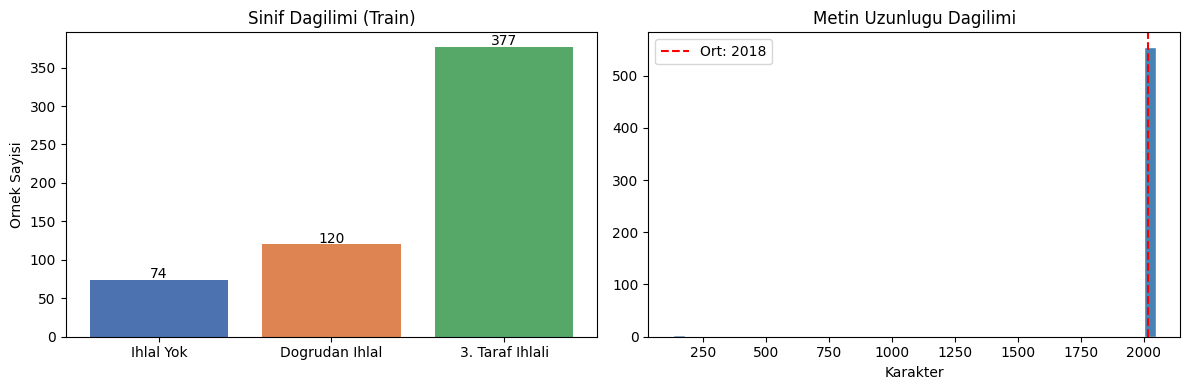

Grafik kaydedildi.


In [10]:
import pandas as pd, matplotlib.pyplot as plt, json
from collections import Counter

train_df = pd.read_csv("data/train.csv")
val_df   = pd.read_csv("data/val.csv")
test_df  = pd.read_csv("data/test.csv")

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

LABEL_NAMES = {0: "Ihlal Yok", 1: "Dogrudan Ihlal", 2: "3. Taraf Ihlali"}

# Sinif dagilimi
cnt = Counter(train_df["label"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(
    [LABEL_NAMES[l] for l in sorted(cnt)],
    [cnt[l] for l in sorted(cnt)],
    color=["#4C72B0", "#DD8452", "#55A868"]
)
axes[0].set_title("Sinif Dagilimi (Train)")
axes[0].set_ylabel("Ornek Sayisi")
for bar, (l, n) in zip(bars, sorted(cnt.items())):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+2, str(n), ha='center', fontsize=10)

# Metin uzunlugu
train_df["char_len"] = train_df["text"].str.len()
axes[1].hist(train_df["char_len"], bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(train_df["char_len"].mean(), color="red", linestyle="--",
                label=f"Ort: {train_df['char_len'].mean():.0f}")
axes[1].set_title("Metin Uzunlugu Dagilimi")
axes[1].set_xlabel("Karakter")
axes[1].legend()

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/data_overview.png", dpi=120)
plt.show()
print("Grafik kaydedildi.")

CTI Analisti Etiket Dogrulama data_prep.py heuristik etiketleme yapiyor.

In [11]:
# Class 1 (Dogrudan Ihlal) orneklerini incele
class1_df = train_df[train_df["label"] == 1].head(10)
for _, row in class1_df.iterrows():
    print(f"URL: {row.get('url', '-')}")
    print(f"Metin (ilk 200 kar): {row['text'][:200]}")
    print("-" * 60)

URL: https://krebsonsecurity.com/2017/09/canadian-man-gets-9-months-detention-for-serial-swattings-bomb-threats/
Metin (ilk 200 kar): Title: Canadian Man Gets 9 Months Detention for Serial Swattings, Bomb Threats [SEP] Content: A 19-year-old Canadian man was found guilty of making almost three dozen fraudulent calls to emergency ser
------------------------------------------------------------
URL: https://krebsonsecurity.com/2024/11/feds-charge-five-men-in-scattered-spider-roundup/
Metin (ilk 200 kar): Title: Feds Charge Five Men in ‘Scattered Spider’ Roundup [SEP] Content: Federal prosecutors in Los Angeles this week unsealed criminal charges against five men alleged to be members of a hacking grou
------------------------------------------------------------
URL: https://krebsonsecurity.com/2021/02/mexican-politician-removed-over-alleged-ties-to-romanian-atm-skimmer-gang/
Metin (ilk 200 kar): Title: Mexican Politician Removed Over Alleged Ties to Romanian ATM Skimmer Gang [SEP] Conten

4. Model Konfigurasyonu

In [12]:
MODELS = {
    "smollm2"  : "HuggingFaceTB/SmolLM2-360M-Instruct",
    "tinyllama": "unsloth/tinyllama-chat-bnb-4bit",
    "qwen"     : "unsloth/qwen2.5-1.5b-instruct-bnb-4bit",
    "gemma"    : "unsloth/gemma-2-2b-it-bnb-4bit",
}

SELECTED_MODELS = ["smollm2", "tinyllama", "qwen","gemma"]
QUANTIZE        = {"tinyllama","qwen", "gemma"}                   # bu modeller 4-bit

print("Secili modeller:")
for k in SELECTED_MODELS:
    q = "(QLoRA 4-bit)" if k in QUANTIZE else "(LoRA FP16)"
    print(f"  {k:12s} {q}  ->  {MODELS[k]}")

Secili modeller:
  smollm2      (LoRA FP16)  ->  HuggingFaceTB/SmolLM2-360M-Instruct
  tinyllama    (QLoRA 4-bit)  ->  unsloth/tinyllama-chat-bnb-4bit
  qwen         (QLoRA 4-bit)  ->  unsloth/qwen2.5-1.5b-instruct-bnb-4bit
  gemma        (QLoRA 4-bit)  ->  unsloth/gemma-2-2b-it-bnb-4bit


5. Zero-Shot Baseline

In [14]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps xformers trl peft accelerate bitsandbytes datasets

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-767t4vfl/unsloth_1ea663b7b64d494b9593166b5254c358
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-767t4vfl/unsloth_1ea663b7b64d494b9593166b5254c358
  Resolved https://github.com/unslothai/unsloth.git to commit e0ff6a1404e92f91d483a0e48e8785700814a97b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.2/924.2 kB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 119.6 MB/s eta 0:00:0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 50.1 MB/s eta 0:00:00


In [4]:
import json
from sklearn.model_selection import train_test_split

# Dosya adları (Uzantı yazmayı unuttuysan diye try-except ile yakalayacağız)
file_3rd_party = "third_party_news.json"
file_non_3rd_party = "not_third_party_news.json"

def load_data(filename, label):
    try:
        with open(filename, "r", encoding="utf-8") as f:
            data = json.load(f)
    except FileNotFoundError:
        # Uzantı eksiğini tolere et
        with open(filename + ".json", "r", encoding="utf-8") as f:
            data = json.load(f)

    formatted = []
    for item in data:
        formatted.append({
            "instruction": "You are a CTI expert. Classify the data breach: 1 (Internal Breach) or 2 (3rd Party Breach). Reply ONLY with the number 1 or 2.",
            "input": f"Title: {item.get('title', '')}\nContent: {item.get('content', '')[:1000]}",
            "output": str(label)
        })
    return formatted

print("1. Dosyalar okunuyor ve etiketleniyor...")
data_3rd = load_data(file_3rd_party, label=2)       # 3. Taraf -> Sınıf 2
data_non_3rd = load_data(file_non_3rd_party, label=1) # İç İhlal -> Sınıf 1

all_data = data_3rd + data_non_3rd
print(f"Toplam okunan veri: {len(all_data)} (3. Taraf: {len(data_3rd)}, İç İhlal: {len(data_non_3rd)})")

print("2. Veri Train/Val/Test olarak (Seed=42) bölünüyor...")
train_data, temp_test_data = train_test_split(all_data, test_size=0.20, random_state=42, stratify=[x["output"] for x in all_data])
val_data, test_data = train_test_split(temp_test_data, test_size=0.50, random_state=42, stratify=[x["output"] for x in temp_test_data])

def save_jsonl(data_list, filename):
    with open(filename, "w", encoding="utf-8") as f:
        for item in data_list:
            f.write(json.dumps(item, ensure_ascii=False) + "\n")

save_jsonl(train_data, "train.jsonl")
save_jsonl(val_data, "val.jsonl")
save_jsonl(test_data, "test.jsonl")

print("3. İŞLEM TAMAM! test.jsonl dosyası oluşturuldu, teste hazırız.")

1. Dosyalar okunuyor ve etiketleniyor...
Toplam okunan veri: 717 (3. Taraf: 417, İç İhlal: 300)
2. Veri Train/Val/Test olarak (Seed=42) bölünüyor...
3. İŞLEM TAMAM! test.jsonl dosyası oluşturuldu, teste hazırız.


In [5]:
import json
import time
import torch
from unsloth import FastLanguageModel
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report

ZERO_SHOT_MODEL = "unsloth/tinyllama-chat-bnb-4bit"
print(f"Zero-shot modeli yukleniyor: {ZERO_SHOT_MODEL}")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = ZERO_SHOT_MODEL,
    max_seq_length = 1024,
    dtype = None,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)

print("Test verisi okunuyor...")
texts, labels = [], []
with open("test.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        texts.append(item["input"])
        labels.append(int(item["output"]))

alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
You are a CTI expert. Classify the data breach: 1 (Internal Breach) or 2 (3rd Party Breach). Reply ONLY with the number 1 or 2.

### Input:
{}

### Response:
"""

preds, t0 = [], time.time()
print(f"Test Başlıyor (n={len(texts)})...")

for text in tqdm(texts, desc="Çıkarım Yapılıyor"):
    prompt = alpaca_prompt.format(text)
    inputs = tokenizer([prompt], return_tensors = "pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens = 2, use_cache = True)
    generated_text = tokenizer.batch_decode(outputs, skip_special_tokens = True)[0]

    response_part = generated_text.split("### Response:\n")[-1].strip()
    digits = [c for c in response_part if c in "12"]
    preds.append(int(digits[0]) if digits else 1)

elapsed = (time.time() - t0) * 1000 / len(texts)

print("\n--- Zero-Shot Sonuclari (TinyLlama) ---")
print(f"  Accuracy      : {accuracy_score(labels, preds):.4f}")
print(f"  Macro-F1      : {f1_score(labels, preds, average='macro', zero_division=0):.4f}")
print(f"  Weighted-F1   : {f1_score(labels, preds, average='weighted', zero_division=0):.4f}")
print(f"  Hız (ms/ornek): {elapsed:.1f}")

Zero-shot modeli yukleniyor: unsloth/tinyllama-chat-bnb-4bit
==((====))==  Unsloth 2026.5.10: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Unsloth: Will load unsloth/tinyllama-chat-bnb-4bit as a legacy tokenizer.


Test verisi okunuyor...
Test Başlıyor (n=72)...


Çıkarım Yapılıyor:   0%|          | 0/72 [00:00<?, ?it/s]

Both `max_new_tokens` (=2) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/di


--- Zero-Shot Sonuclari (TinyLlama) ---
  Accuracy      : 0.4167
  Macro-F1      : 0.2941
  Weighted-F1   : 0.2451
  Hız (ms/ornek): 201.9


In [6]:
!pip install -U bitsandbytes triton

6. Fine-Tuning

In [7]:
import gc
import torch
from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import load_dataset
import os

os.makedirs("outputs", exist_ok=True)

# 1. Modele Özel Dinamik Yapılandırma (OOM Kalkanı)
MODEL_CONFIGS = {
    "smollm2":   {"name": "HuggingFaceTB/SmolLM2-360M-Instruct", "batch_size": 8, "quantize": False},
    "tinyllama": {"name": "unsloth/tinyllama-chat-bnb-4bit",     "batch_size": 4, "quantize": True},
    "qwen":      {"name": "unsloth/qwen2.5-1.5b-instruct-bnb-4bit", "batch_size": 2, "quantize": True},
    "gemma":     {"name": "unsloth/gemma-2-2b-it-bnb-4bit",      "batch_size": 2, "quantize": True} # En ağır model
}

# 2. Veri Seti Hazırlığı
dataset = load_dataset("json", data_files={"train": "train.jsonl"}, split="train")

alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

def format_prompts(examples):
    texts = []
    for inst, inp, out in zip(examples["instruction"], examples["input"], examples["output"]):
        # Modelin nerede duracağını bilmesi için EOS (End of Sequence) ekliyoruz
        texts.append(alpaca_prompt.format(inst, inp, out) + "<|endoftext|>")
    return {"text": texts}

train_dataset = dataset.map(format_prompts, batched=True)

# 3. Otomatik Eğitim Döngüsü
for model_key, config in MODEL_CONFIGS.items():
    print(f"\n{'='*70}")
    print(f"🚀 BAŞLIYOR: {model_key.upper()} | Batch Size: {config['batch_size']} | Quantize: {config['quantize']}")
    print(f"{'='*70}")

    # Modeli Yükle
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = config["name"],
        max_seq_length = 1024,
        dtype = None,
        load_in_4bit = config["quantize"]
    )

    # LoRA Adaptörlerini Tak
    model = FastLanguageModel.get_peft_model(
        model,
        r = 16,
        target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        lora_alpha = 32, # Senin scriptindeki gibi 32 yaptık
        lora_dropout = 0,
        bias = "none",
        use_gradient_checkpointing = "unsloth",
        random_state = 42,
    )

    # Eğitimi Başlat
    trainer = SFTTrainer(
        model = model,
        tokenizer = tokenizer,
        train_dataset = train_dataset,
        dataset_text_field = "text",
        max_seq_length = 1024,
        dataset_num_proc = 2,
        args = TrainingArguments(
            per_device_train_batch_size = config["batch_size"], # Modele özel batch size
            gradient_accumulation_steps = 4,
            warmup_steps = 5,
            num_train_epochs = 5, # Senin komutundaki gibi 5 epoch
            learning_rate = 2e-4,
            fp16 = not torch.cuda.is_bf16_supported(),
            bf16 = torch.cuda.is_bf16_supported(),
            logging_steps = 10,
            optim = "adamw_8bit",
            seed = 42,
            output_dir = f"outputs/{model_key}",
        ),
    )

    trainer.train()

    # Kayıt İşlemi
    save_path = f"lora_{model_key}"
    model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"✅ TAMAMLANDI VE KAYDEDİLDİ: {save_path}")

    # 4. KRİTİK ADIM: VRAM TEMİZLİĞİ (OOM YEMEMEK İÇİN)
    del model
    del tokenizer
    del trainer
    gc.collect()
    torch.cuda.empty_cache()
    print(f"🧹 VRAM Temizlendi, bir sonraki modele geçiliyor...\n")

print("🎉 4 MODELİN EĞİTİMİ BAŞARIYLA TAMAMLANDI!")

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/573 [00:00<?, ? examples/s]


🚀 BAŞLIYOR: SMOLLM2 | Batch Size: 8 | Quantize: False
==((====))==  Unsloth 2026.5.10: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

...

Step,Training Loss
10,24.789818
20,16.475061
30,10.081639
40,8.247015
50,7.618884
60,7.162980
70,7.035049
80,6.970341
90,6.609395
100,6.361824


Unsloth: Restored added_tokens_decoder metadata in outputs/gemma/checkpoint-360/tokenizer_config.json.


tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

Unsloth: Preserved sentencepiece asset `tokenizer.model` in outputs/gemma/checkpoint-360.
Unsloth: Restored added_tokens_decoder metadata in lora_gemma/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in lora_gemma.


✅ TAMAMLANDI VE KAYDEDİLDİ: lora_gemma
🧹 VRAM Temizlendi, bir sonraki modele geçiliyor...

🎉 4 MODELİN EĞİTİMİ BAŞARIYLA TAMAMLANDI!


7. Test Seti Degerlendirme & Karsilastirma

In [8]:
import json
import time
import torch
import gc
import pandas as pd
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, f1_score
from unsloth import FastLanguageModel

# Kaydettiğimiz modellerin klasör isimleri
trained_models = ["lora_smollm2", "lora_tinyllama", "lora_qwen", "lora_gemma"]

print("1. Test verisi okunuyor...")
texts, labels = [], []
with open("test.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        texts.append(item["input"])
        labels.append(int(item["output"]))

alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
You are a CTI expert. Classify the data breach: 1 (Internal Breach) or 2 (3rd Party Breach). Reply ONLY with the number 1 or 2.

### Input:
{}

### Response:
"""

results = []

print(f"\n🏆 BÜYÜK FİNAL: {len(trained_models)} Modelin Test Seti (n={len(texts)}) Değerlendirmesi Başlıyor...\n")

for model_path in trained_models:
    print(f"🔄 [{model_path.upper()}] Yükleniyor...")

    # Modeli Yükle (4-bit inference)
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = model_path,
        max_seq_length = 1024,
        dtype = None,
        load_in_4bit = True,
    )
    FastLanguageModel.for_inference(model)

    preds = []
    t0 = time.time()

    for text in tqdm(texts, desc=f"Çıkarım ({model_path.replace('lora_','')})"):
        prompt = alpaca_prompt.format(text)
        inputs = tokenizer([prompt], return_tensors = "pt").to("cuda")

        outputs = model.generate(**inputs, max_new_tokens = 2, use_cache = True)
        generated_text = tokenizer.batch_decode(outputs, skip_special_tokens = True)[0]

        response_part = generated_text.split("### Response:\n")[-1].strip()
        digits = [c for c in response_part if c in "12"]
        preds.append(int(digits[0]) if digits else 1)

    elapsed = (time.time() - t0) * 1000 / len(texts)

    # Metrik Hesaplamaları
    acc = accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average="macro", zero_division=0)
    wf1 = f1_score(labels, preds, average="weighted", zero_division=0)

    # Tablo için kaydet
    results.append({
        "Model": model_path.replace("lora_", "").upper(),
        "Accuracy": round(acc, 4),
        "Macro-F1": round(mf1, 4),
        "Weighted-F1": round(wf1, 4),
        "Hız (ms/örnek)": round(elapsed, 1)
    })

    # 🧹 OOM YEMEMEK İÇİN KRİTİK TEMİZLİK
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()

print("\n" + "="*60)
print(" 📊 FİNAL KARŞILAŞTIRMA TABLOSU (HOCA İÇİN)")
print("="*60)
df = pd.DataFrame(results)
print(df.to_string(index=False))
print("="*60)

1. Test verisi okunuyor...

🏆 BÜYÜK FİNAL: 4 Modelin Test Seti (n=72) Değerlendirmesi Başlıyor...

🔄 [LORA_SMOLLM2] Yükleniyor...
==((====))==  Unsloth 2026.5.10: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


HuggingFaceTB/SmolLM2-360M-Instruct does not have a padding token! Will use pad_token = <|endoftext|>.


Çıkarım (smollm2):   0%|          | 0/72 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Unsloth: Will load unsloth/gemma-2-2b-it-bnb-4bit as a legacy tokenizer.


Çıkarım (gemma):   0%|          | 0/72 [00:00<?, ?it/s]

Both `max_new_tokens` (=2) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/di


 📊 FİNAL KARŞILAŞTIRMA TABLOSU (HOCA İÇİN)
    Model  Accuracy  Macro-F1  Weighted-F1  Hız (ms/örnek)
  SMOLLM2    0.7500    0.7402       0.7486           240.1
TINYLLAMA    1.0000    1.0000       1.0000           173.8
     QWEN    1.0000    1.0000       1.0000           255.4
    GEMMA    0.4167    0.2941       0.2451           490.6


✅ final_results.csv diske kaydedildi.

--- Model Performans Karşılaştırması ---


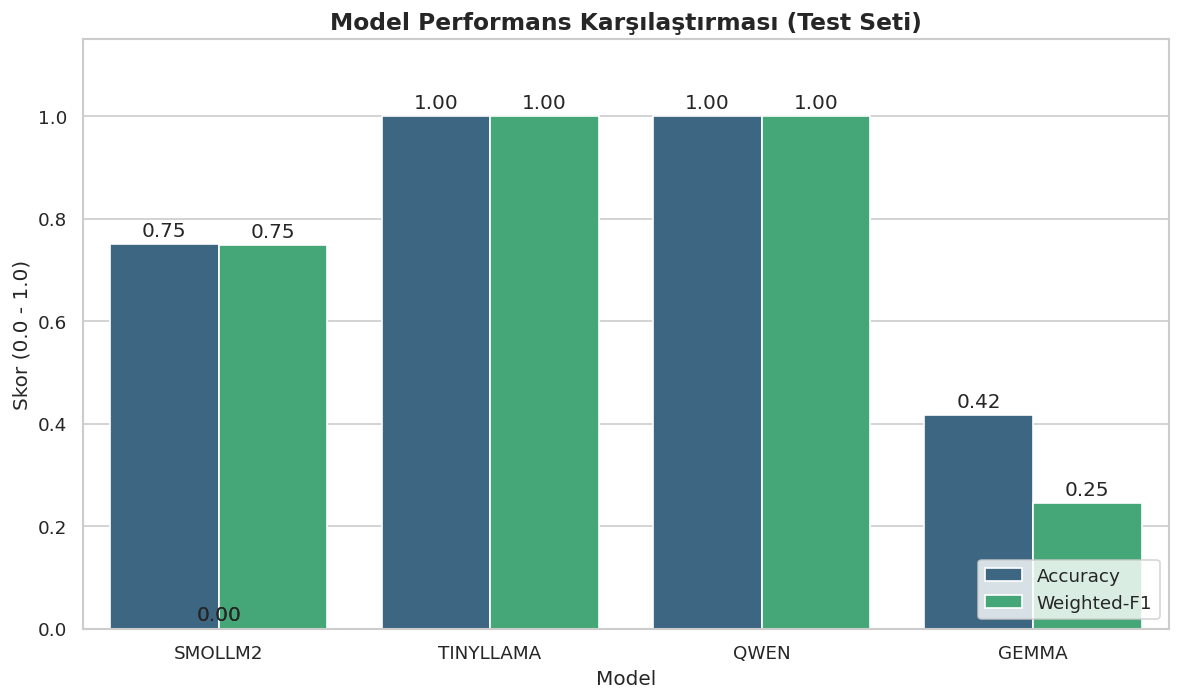


--- Verimlilik Analizi ---


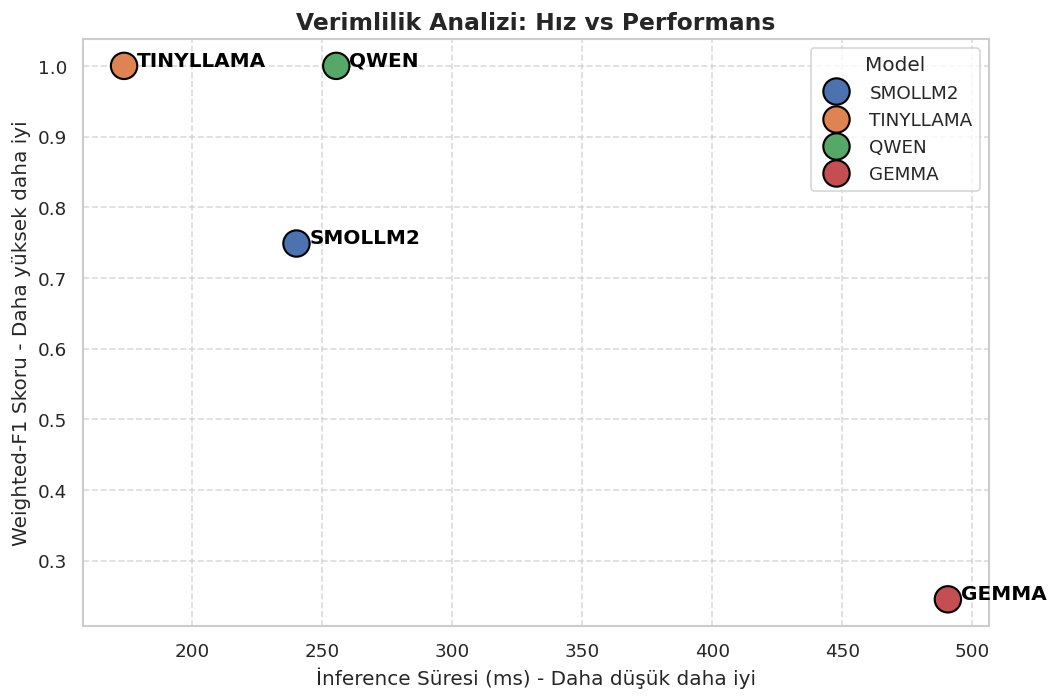

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Klasör kontrolü
os.makedirs("outputs", exist_ok=True)

# Çıkan güncel sonuçlarımız
data = [
    {"Model": "SMOLLM2", "Accuracy": 0.7500, "Macro-F1": 0.7402, "Weighted-F1": 0.7486, "Hız (ms/örnek)": 240.1},
    {"Model": "TINYLLAMA", "Accuracy": 1.0000, "Macro-F1": 1.0000, "Weighted-F1": 1.0000, "Hız (ms/örnek)": 173.8},
    {"Model": "QWEN", "Accuracy": 1.0000, "Macro-F1": 1.0000, "Weighted-F1": 1.0000, "Hız (ms/örnek)": 255.4},
    {"Model": "GEMMA", "Accuracy": 0.4167, "Macro-F1": 0.2941, "Weighted-F1": 0.2451, "Hız (ms/örnek)": 490.6}
]

df = pd.DataFrame(data)
df.to_csv("outputs/final_results.csv", index=False)
print("✅ final_results.csv diske kaydedildi.\n")

# Çizim kalitesini artırıyoruz
plt.rcParams['figure.dpi'] = 120

# --- GRAFİK 1: Model Karşılaştırma (Accuracy & F1) ---
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
df_melted = df.melt(id_vars="Model", value_vars=["Accuracy", "Weighted-F1"], var_name="Metrik", value_name="Skor")

ax = sns.barplot(x="Model", y="Skor", hue="Metrik", data=df_melted, palette="viridis")
plt.title("Model Performans Karşılaştırması (Test Seti)", fontsize=14, fontweight='bold')
plt.ylim(0, 1.15) # Etiketler sığsın diye tavanı biraz yükselttik
plt.ylabel("Skor (0.0 - 1.0)")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("outputs/model_comparison.png", dpi=300) # Önce diske kaydet
print("--- Model Performans Karşılaştırması ---")
plt.show() # Sonra Colab ekranına bas
plt.close()

# --- GRAFİK 2: Verimlilik Grafiği (F1 vs Inference Hızı) ---
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Hız (ms/örnek)", y="Weighted-F1", hue="Model", s=250, palette="deep", edgecolor="black")

# Noktalara model isimlerini hizalı yaz
for i in range(df.shape[0]):
    plt.text(df["Hız (ms/örnek)"][i] + 5, df["Weighted-F1"][i], df["Model"][i],
             horizontalalignment='left', size='medium', color='black', weight='semibold')

plt.title("Verimlilik Analizi: Hız vs Performans", fontsize=14, fontweight='bold')
plt.xlabel("İnference Süresi (ms) - Daha düşük daha iyi")
plt.ylabel("Weighted-F1 Skoru - Daha yüksek daha iyi")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("outputs/efficiency_plot.png", dpi=300) # Önce diske kaydet
print("\n--- Verimlilik Analizi ---")
plt.show() # Sonra Colab ekranına bas
plt.close()

8. Hata Analizi (CTI Analisti Perspektifi)

In [11]:
import json
import torch
from unsloth import FastLanguageModel
from tqdm.notebook import tqdm
import gc

# 1. Hata analizi için hata yapmış bir modeli seçiyoruz (TinyLlama %100 yaptığı için ondan hata çıkmaz)
ERROR_ANALYSIS_MODEL = "lora_smollm2"

print(f"🔍 CTI Hata Analizi Başlıyor. Model: {ERROR_ANALYSIS_MODEL.upper()}")

# 2. Modeli Yükle (4-bit inference modu)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = ERROR_ANALYSIS_MODEL,
    max_seq_length = 1024,
    dtype = None,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)

# 3. Test verisini oku
texts, true_labels = [], []
with open("test.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        texts.append(item["input"])
        true_labels.append(int(item["output"]))

alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
You are a CTI expert. Classify the data breach: 1 (Internal Breach) or 2 (3rd Party Breach). Reply ONLY with the number 1 or 2.

### Input:
{}

### Response:
"""

errors = []
class_names = {1: "İç İhlal (1)", 2: "3. Taraf İhlali (2)"}

# 4. Çıkarım ve Hata Avı
for idx, (text, true_label) in enumerate(tqdm(zip(texts, true_labels), total=len(texts), desc="Hatalar Aranıyor")):
    prompt = alpaca_prompt.format(text)
    inputs = tokenizer([prompt], return_tensors = "pt").to("cuda")

    outputs = model.generate(**inputs, max_new_tokens = 2, use_cache = True)
    generated_text = tokenizer.batch_decode(outputs, skip_special_tokens = True)[0]

    response_part = generated_text.split("### Response:\n")[-1].strip()
    digits = [c for c in response_part if c in "12"]
    pred_label = int(digits[0]) if digits else 1 # Hata yaparsa default 1

    # EĞER TAHMİN YANLIŞSA KAYDET
    if pred_label != true_label:
        # Haberin başlığını ve ilk 250 karakterini temizleyerek alıyoruz
        clean_text = text.replace("Title: ", "").replace("Content: ", "").strip()
        errors.append({
            "idx": idx,
            "text_snippet": clean_text[:250],
            "true_name": class_names[true_label],
            "pred_name": class_names[pred_label]
        })

# 5. VRAM Temizliği (Her zaman önce temizlik!)
del model
del tokenizer
gc.collect()
torch.cuda.empty_cache()

# 6. Sonuçları Raporla
print(f"\n🚨 Toplam {len(errors)} hata bulundu.")
print("--- İlk 5 Yanlış Sınıflandırma (CTI Analisti Gözüyle) ---\n")

for e in errors[:5]:
    print(f"📍 İndeks [{e['idx']}] | Gerçek = {e['true_name']}  ❌  Tahmin = {e['pred_name']}")
    print(f"📝 Metin: {e['text_snippet']}...\n")
    print("-" * 75)

🔍 CTI Hata Analizi Başlıyor. Model: LORA_SMOLLM2
==((====))==  Unsloth 2026.5.10: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


HuggingFaceTB/SmolLM2-360M-Instruct does not have a padding token! Will use pad_token = <|endoftext|>.


Hatalar Aranıyor:   0%|          | 0/72 [00:00<?, ?it/s]

Both `max_new_tokens` (=2) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=2) a


🚨 Toplam 18 hata bulundu.
--- İlk 5 Yanlış Sınıflandırma (CTI Analisti Gözüyle) ---

📍 İndeks [1] | Gerçek = İç İhlal (1)  ❌  Tahmin = 3. Taraf İhlali (2)
📝 Metin: Microsoft Patch Tuesday, December 2022 Edition
Microsofthas released its final monthly batch of security updates for 2022, fixing more than four dozen security holes in its variousWindowsoperating systems and related software. The most pressing patch...

---------------------------------------------------------------------------
📍 İndeks [7] | Gerçek = İç İhlal (1)  ❌  Tahmin = 3. Taraf İhlali (2)
📝 Metin: The Stark Truth Behind the Resurgence of Russia’s Fin7
The Russia-based cybercrime group dubbed “Fin7,” known for phishing and malware attacks that have cost victim organizations an estimated $3 billion in losses since 2013, was declared dead last ye...

---------------------------------------------------------------------------
📍 İndeks [13] | Gerçek = 3. Taraf İhlali (2)  ❌  Tahmin = İç İhlal (1)
📝 Metin: Discord disclo

9. Sonuclari Drive'a Kaydet

In [13]:
import os
import shutil
import datetime
from google.colab import drive

# Google Drive bağlı değilse bağlayalım
if not os.path.exists("/content/drive"):
    drive.mount('/content/drive')

# Zaman damgası ve hedef klasör oluşturma
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M")
save_dir = f"/content/drive/MyDrive/third_party_breach_results_{ts}"
os.makedirs(save_dir, exist_ok=True)

# Yeni yapıda ürettiğimiz güncel ve kritik dosyaların listesi
files_to_copy = [
    "outputs/final_results.csv",
    "outputs/model_comparison.png",
    "outputs/efficiency_plot.png",
    "outputs/tum_hatalar_analiz.txt", # Yeni detaylı hata raporumuz
    "train.jsonl",                    # Eğitilen veri seti
    "val.jsonl",                      # Doğrulama veri seti
    "test.jsonl"                      # Test veri seti
]

# Kopyalama işlemi
for fname in files_to_copy:
    if os.path.exists(fname):
        shutil.copy(fname, save_dir)

print(f"Tüm güncel sonuçlar ve veri setleri Drive'a yedeklendi:\n  {save_dir}")

Tüm güncel sonuçlar ve veri setleri Drive'a yedeklendi:
  /content/drive/MyDrive/third_party_breach_results_20260601_2007
